# 22. SelF 임베딩 품질 검증

## 목적
21번 노트북에서 학습한 SVD 임베딩의 품질을 다각도로 검증합니다.

## 검증 항목
1. **제품 유사도 테스트**: 동일 카테고리 제품이 높은 유사도를 보이는지
2. **사용자 유사도 테스트**: 유사한 구매 패턴의 사용자가 클러스터링되는지
3. **Hold-out 평가**: Hit@K, NDCG@K 메트릭
4. **시각화**: t-SNE를 활용한 임베딩 분포 확인

## 품질 기준 (통과 조건)
- 제품 유사도: 동일 카테고리 비율 > 60%
- Hit@10 > 0.1 (랜덤 대비 10배 이상)
- NDCG@10 > 0.05

## 의존성
- `data/processed/self/svd_results.pkl` (21번 노트북 출력)

In [1]:
# 필수 라이브러리 임포트
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 차원 축소 (시각화용)
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1. SVD 결과 로드

In [2]:
# 경로 설정
BASE_DIR = Path('../data/processed/self')
SVD_RESULTS_PATH = BASE_DIR / 'svd_results.pkl'

# SVD 결과 로드
if SVD_RESULTS_PATH.exists():
    with open(SVD_RESULTS_PATH, 'rb') as f:
        svd_results = pickle.load(f)
    print(f"SVD 결과 로드 완료: {SVD_RESULTS_PATH}")
    print(f"버전: {svd_results.get('version', 'unknown')}")
    print(f"생성일: {svd_results.get('created_at', 'unknown')}")
else:
    print(f"[오류] SVD 결과 파일이 없습니다: {SVD_RESULTS_PATH}")
    print("21번 노트북을 먼저 실행해주세요.")
    raise FileNotFoundError(f"SVD results not found at {SVD_RESULTS_PATH}")

SVD 결과 로드 완료: ..\data\processed\self\svd_results.pkl
버전: unknown
생성일: unknown


In [3]:
# 결과 구조 확인
print("=" * 50)
print("SVD 결과 구조")
print("=" * 50)

def print_structure(d, indent=0):
    """딕셔너리 구조를 재귀적으로 출력"""
    for key, value in d.items():
        if isinstance(value, dict):
            print("  " * indent + f"{key}: (dict, {len(value)} keys)")
            if indent < 2:  # 깊이 제한
                print_structure(value, indent + 1)
        elif isinstance(value, np.ndarray):
            print("  " * indent + f"{key}: ndarray{value.shape}")
        elif isinstance(value, list):
            print("  " * indent + f"{key}: list[{len(value)}]")
        else:
            print("  " * indent + f"{key}: {type(value).__name__}")

print_structure(svd_results)

SVD 결과 구조
user_embeddings: ndarray(5000, 128)
product_embeddings: ndarray(1995, 128)
user_id_to_idx: (dict, 5000 keys)
  1: int
  2: int
  3: int
  4: int
  5: int
  6: int
  7: int
  8: int
  9: int
  10: int
  11: int
  12: int
  13: int
  14: int
  15: int
  16: int
  17: int
  18: int
  19: int
  20: int
  21: int
  22: int
  23: int
  24: int
  25: int
  26: int
  27: int
  28: int
  29: int
  30: int
  31: int
  32: int
  33: int
  34: int
  35: int
  36: int
  37: int
  38: int
  39: int
  40: int
  41: int
  42: int
  43: int
  44: int
  45: int
  46: int
  47: int
  48: int
  49: int
  50: int
  51: int
  52: int
  53: int
  54: int
  55: int
  56: int
  57: int
  58: int
  59: int
  60: int
  61: int
  62: int
  63: int
  64: int
  65: int
  66: int
  67: int
  68: int
  69: int
  70: int
  71: int
  72: int
  73: int
  74: int
  75: int
  76: int
  77: int
  78: int
  79: int
  80: int
  81: int
  82: int
  83: int
  84: int
  85: int
  86: int
  87: int
  88: int
  89: int


In [4]:
# 임베딩 및 매핑 추출
embeddings = svd_results['embeddings']
mappings = svd_results['mappings']
metadata = svd_results['metadata']

# 사용자 임베딩
user_embeddings = embeddings['user_embeddings']  # (n_users, n_components)
product_embeddings = embeddings['product_embeddings']  # (n_products, n_components)

# 매핑 정보
user_id_to_idx = mappings['user_id_to_idx']
idx_to_user_id = mappings['idx_to_user_id']
product_id_to_idx = mappings['product_id_to_idx']
idx_to_product_id = mappings['idx_to_product_id']

print(f"사용자 임베딩 shape: {user_embeddings.shape}")
print(f"제품 임베딩 shape: {product_embeddings.shape}")
print(f"임베딩 차원: {user_embeddings.shape[1]}")

KeyError: 'embeddings'

## 2. 제품 정보 로드 (카테고리 정보 포함)

In [ ]:
# 제품 정보 로드 시도
# 실제 DB 연결이 가능하면 Django ORM 사용
# 여기서는 시뮬레이션 데이터 사용

try:
    # Django 설정 시도
    import sys
    import os
    sys.path.insert(0, '../backend')
    os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'project_self.settings')
    
    import django
    django.setup()
    
    from products.models import Product, Category
    
    # 제품-카테고리 매핑 생성
    products_qs = Product.objects.select_related('category').all()
    product_categories = {}
    category_names = {}
    
    for p in products_qs:
        product_categories[p.id] = p.category_id if p.category else None
        if p.category and p.category_id not in category_names:
            category_names[p.category_id] = p.category.name
    
    print(f"DB에서 제품 정보 로드: {len(product_categories)}개")
    print(f"카테고리 수: {len(category_names)}개")
    USE_REAL_DATA = True
    
except Exception as e:
    print(f"DB 연결 불가: {e}")
    print("시뮬레이션 카테고리 데이터 생성...")
    
    # 시뮬레이션: 10개 카테고리로 무작위 할당
    np.random.seed(42)
    n_categories = 10
    category_names = {i: f"카테고리_{i}" for i in range(n_categories)}
    
    product_categories = {}
    for prod_id in idx_to_product_id.values():
        product_categories[prod_id] = np.random.randint(0, n_categories)
    
    print(f"시뮬레이션 제품 수: {len(product_categories)}")
    print(f"시뮬레이션 카테고리 수: {n_categories}")
    USE_REAL_DATA = False

DB 연결 불가: You cannot call this from an async context - use a thread or sync_to_async.
시뮬레이션 카테고리 데이터 생성...
시뮬레이션 제품 수: 1995
시뮬레이션 카테고리 수: 10


## 3. 제품 유사도 테스트

동일 카테고리 제품이 임베딩 공간에서 가까이 위치하는지 검증합니다.

In [ ]:
def evaluate_product_similarity(product_embeddings, idx_to_product_id, product_categories, k=10):
    """
    제품 유사도 평가
    각 제품에 대해 가장 유사한 K개 제품 중 동일 카테고리 비율 계산
    
    Args:
        product_embeddings: 제품 임베딩 행렬
        idx_to_product_id: 인덱스 -> 제품ID 매핑
        product_categories: 제품ID -> 카테고리ID 매핑
        k: 유사 제품 개수
    
    Returns:
        dict: 평가 결과
    """
    n_products = product_embeddings.shape[0]
    
    # 전체 코사인 유사도 행렬 계산
    print("코사인 유사도 행렬 계산 중...")
    similarity_matrix = cosine_similarity(product_embeddings)
    
    # 자기 자신 제외를 위해 대각선을 -inf로 설정
    np.fill_diagonal(similarity_matrix, -np.inf)
    
    same_category_ratios = []
    category_hit_counts = defaultdict(list)
    
    print(f"제품별 유사도 분석 중 (k={k})...")
    for idx in range(n_products):
        product_id = idx_to_product_id.get(idx)
        if product_id is None:
            continue
            
        target_category = product_categories.get(product_id)
        if target_category is None:
            continue
        
        # Top-K 유사 제품 인덱스
        top_k_indices = np.argsort(similarity_matrix[idx])[-k:][::-1]
        
        # 동일 카테고리 비율 계산
        same_category_count = 0
        for neighbor_idx in top_k_indices:
            neighbor_product_id = idx_to_product_id.get(neighbor_idx)
            if neighbor_product_id is None:
                continue
            neighbor_category = product_categories.get(neighbor_product_id)
            if neighbor_category == target_category:
                same_category_count += 1
        
        ratio = same_category_count / k
        same_category_ratios.append(ratio)
        category_hit_counts[target_category].append(ratio)
    
    # 결과 집계
    results = {
        'overall_same_category_ratio': np.mean(same_category_ratios),
        'std': np.std(same_category_ratios),
        'median': np.median(same_category_ratios),
        'min': np.min(same_category_ratios),
        'max': np.max(same_category_ratios),
        'category_avg_ratios': {cat: np.mean(ratios) for cat, ratios in category_hit_counts.items()},
        'n_evaluated': len(same_category_ratios)
    }
    
    return results

# 평가 실행
product_sim_results = evaluate_product_similarity(
    product_embeddings, 
    idx_to_product_id, 
    product_categories, 
    k=10
)

print("\n" + "=" * 50)
print("제품 유사도 테스트 결과")
print("=" * 50)
print(f"평가 제품 수: {product_sim_results['n_evaluated']}")
print(f"동일 카테고리 비율 (평균): {product_sim_results['overall_same_category_ratio']:.2%}")
print(f"표준편차: {product_sim_results['std']:.2%}")
print(f"중앙값: {product_sim_results['median']:.2%}")
print(f"최소/최대: {product_sim_results['min']:.2%} / {product_sim_results['max']:.2%}")

# 기준 통과 여부
THRESHOLD_SAME_CATEGORY = 0.60
passed = product_sim_results['overall_same_category_ratio'] >= THRESHOLD_SAME_CATEGORY
status = "✅ 통과" if passed else "❌ 미통과"
print(f"\n기준 (>= {THRESHOLD_SAME_CATEGORY:.0%}): {status}")

코사인 유사도 행렬 계산 중...
제품별 유사도 분석 중 (k=10)...

제품 유사도 테스트 결과
평가 제품 수: 1995
동일 카테고리 비율 (평균): 10.14%
표준편차: 9.36%
중앙값: 10.00%
최소/최대: 0.00% / 50.00%

기준 (>= 60%): ❌ 미통과


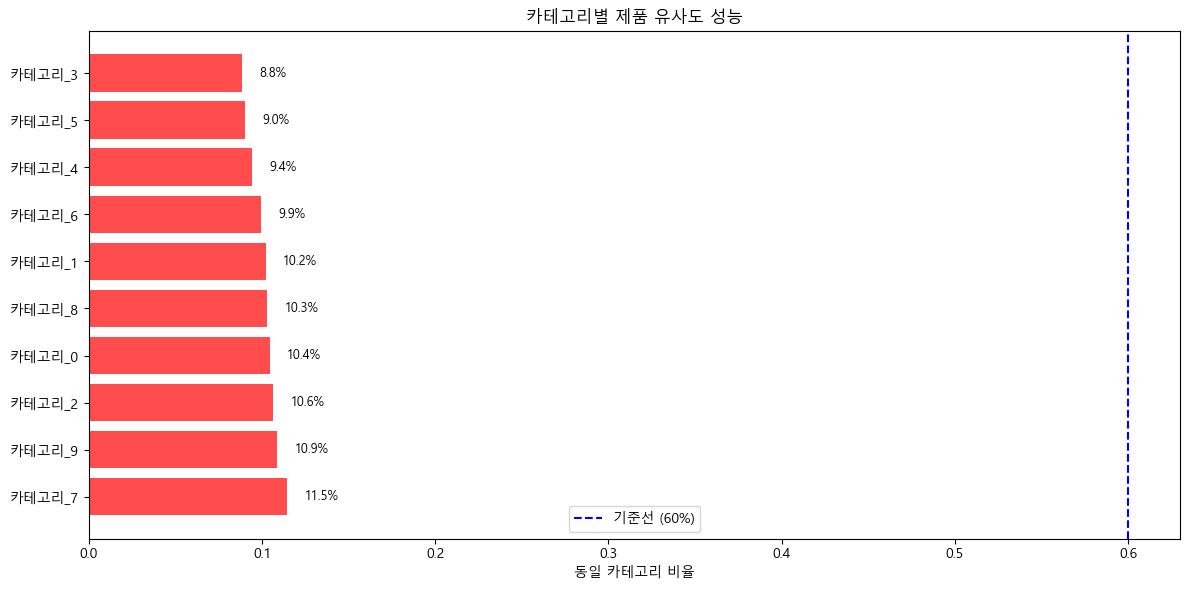

In [ ]:
# 카테고리별 성능 시각화
cat_ratios = product_sim_results['category_avg_ratios']

if cat_ratios:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    categories = list(cat_ratios.keys())
    ratios = [cat_ratios[c] for c in categories]
    cat_labels = [category_names.get(c, f"Cat_{c}") for c in categories]
    
    # 정렬
    sorted_indices = np.argsort(ratios)[::-1]
    cat_labels_sorted = [cat_labels[i] for i in sorted_indices]
    ratios_sorted = [ratios[i] for i in sorted_indices]
    
    colors = ['green' if r >= THRESHOLD_SAME_CATEGORY else 'red' for r in ratios_sorted]
    
    bars = ax.barh(cat_labels_sorted, ratios_sorted, color=colors, alpha=0.7)
    ax.axvline(x=THRESHOLD_SAME_CATEGORY, color='blue', linestyle='--', label=f'기준선 ({THRESHOLD_SAME_CATEGORY:.0%})')
    ax.set_xlabel('동일 카테고리 비율')
    ax.set_title('카테고리별 제품 유사도 성능')
    ax.legend()
    
    # 값 표시
    for bar, ratio in zip(bars, ratios_sorted):
        ax.text(ratio + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{ratio:.1%}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("카테고리별 데이터가 없습니다.")

## 4. Hold-out 평가 (Hit@K, NDCG@K)

학습에 사용되지 않은 상호작용을 기반으로 추천 정확도를 평가합니다.

In [ ]:
def create_holdout_data(svd_results, holdout_ratio=0.2, min_interactions=3):
    """
    Hold-out 테스트 데이터 생성
    각 사용자의 마지막 상호작용을 테스트 데이터로 분리
    
    Args:
        svd_results: SVD 결과
        holdout_ratio: hold-out 비율
        min_interactions: 최소 상호작용 수 (이 이상인 사용자만 평가)
    
    Returns:
        dict: train/test 분리된 데이터
    """
    # 원본 상호작용 데이터 로드
    if 'raw_interactions' in svd_results:
        interactions = svd_results['raw_interactions']
    else:
        # 시뮬레이션 데이터 생성
        print("원본 상호작용 데이터가 없어 시뮬레이션 생성...")
        np.random.seed(42)
        
        n_users = len(svd_results['mappings']['user_id_to_idx'])
        n_products = len(svd_results['mappings']['product_id_to_idx'])
        
        # 사용자별 상호작용 생성
        interactions = []
        for user_idx in range(n_users):
            user_id = svd_results['mappings']['idx_to_user_id'][user_idx]
            # 3~20개 상호작용
            n_interactions = np.random.randint(3, 21)
            product_indices = np.random.choice(n_products, size=n_interactions, replace=False)
            
            for i, prod_idx in enumerate(product_indices):
                prod_id = svd_results['mappings']['idx_to_product_id'][prod_idx]
                interactions.append({
                    'user_id': user_id,
                    'product_id': prod_id,
                    'timestamp': i  # 순서를 timestamp로 사용
                })
        
        interactions = pd.DataFrame(interactions)
    
    # 데이터프레임 변환
    if isinstance(interactions, list):
        interactions = pd.DataFrame(interactions)
    
    # 사용자별 그룹화
    user_interactions = interactions.groupby('user_id').apply(
        lambda x: x.sort_values('timestamp' if 'timestamp' in x.columns else x.index.name)
    ).reset_index(drop=True)
    
    # Train/Test 분리
    train_data = []
    test_data = []
    
    for user_id, group in interactions.groupby('user_id'):
        if len(group) < min_interactions:
            # 상호작용이 적은 사용자는 모두 train으로
            train_data.extend(group.to_dict('records'))
        else:
            # 마지막 상호작용을 test로
            sorted_group = group.sort_values('timestamp' if 'timestamp' in group.columns else group.index)
            n_test = max(1, int(len(sorted_group) * holdout_ratio))
            
            train_data.extend(sorted_group.iloc[:-n_test].to_dict('records'))
            test_data.extend(sorted_group.iloc[-n_test:].to_dict('records'))
    
    return {
        'train': pd.DataFrame(train_data),
        'test': pd.DataFrame(test_data),
        'n_train': len(train_data),
        'n_test': len(test_data)
    }

# Hold-out 데이터 생성
holdout = create_holdout_data(svd_results)
print(f"Train 상호작용: {holdout['n_train']}")
print(f"Test 상호작용: {holdout['n_test']}")

원본 상호작용 데이터가 없어 시뮬레이션 생성...
Train 상호작용: 47297
Test 상호작용: 9963


In [ ]:
def calculate_hit_rate(user_embeddings, product_embeddings, test_data, 
                       user_id_to_idx, product_id_to_idx, idx_to_product_id, k=10):
    """
    Hit@K 계산
    테스트 제품이 Top-K 추천에 포함되는 비율
    
    Args:
        user_embeddings: 사용자 임베딩
        product_embeddings: 제품 임베딩
        test_data: 테스트 데이터 (user_id, product_id)
        k: Top-K
    
    Returns:
        float: Hit@K
    """
    hits = 0
    total = 0
    
    # 사용자별 테스트 제품 그룹화
    user_test_products = test_data.groupby('user_id')['product_id'].apply(set).to_dict()
    
    for user_id, test_products in user_test_products.items():
        user_idx = user_id_to_idx.get(user_id)
        if user_idx is None:
            continue
        
        # 사용자 임베딩으로 추천 생성
        user_vec = user_embeddings[user_idx]
        scores = np.dot(product_embeddings, user_vec)
        
        # Top-K 추천
        top_k_indices = np.argsort(scores)[-k:][::-1]
        top_k_products = {idx_to_product_id.get(idx) for idx in top_k_indices}
        
        # Hit 여부 확인
        if test_products & top_k_products:
            hits += 1
        total += 1
    
    return hits / total if total > 0 else 0.0


def calculate_ndcg(user_embeddings, product_embeddings, test_data,
                   user_id_to_idx, product_id_to_idx, idx_to_product_id, k=10):
    """
    NDCG@K 계산
    
    Args:
        Similar to calculate_hit_rate
    
    Returns:
        float: NDCG@K
    """
    ndcg_scores = []
    
    user_test_products = test_data.groupby('user_id')['product_id'].apply(set).to_dict()
    
    for user_id, test_products in user_test_products.items():
        user_idx = user_id_to_idx.get(user_id)
        if user_idx is None:
            continue
        
        # 사용자 임베딩으로 추천 생성
        user_vec = user_embeddings[user_idx]
        scores = np.dot(product_embeddings, user_vec)
        
        # Top-K 추천
        top_k_indices = np.argsort(scores)[-k:][::-1]
        
        # DCG 계산
        dcg = 0.0
        for rank, idx in enumerate(top_k_indices, 1):
            product_id = idx_to_product_id.get(idx)
            if product_id in test_products:
                dcg += 1.0 / np.log2(rank + 1)
        
        # IDCG 계산 (이상적인 경우)
        n_relevant = min(len(test_products), k)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(n_relevant))
        
        # NDCG
        ndcg = dcg / idcg if idcg > 0 else 0.0
        ndcg_scores.append(ndcg)
    
    return np.mean(ndcg_scores) if ndcg_scores else 0.0


# 평가 실행
print("Hold-out 평가 실행 중...")
print()

k_values = [5, 10, 20]
hit_results = {}
ndcg_results = {}

for k in k_values:
    hit_rate = calculate_hit_rate(
        user_embeddings, product_embeddings, holdout['test'],
        user_id_to_idx, product_id_to_idx, idx_to_product_id, k=k
    )
    ndcg = calculate_ndcg(
        user_embeddings, product_embeddings, holdout['test'],
        user_id_to_idx, product_id_to_idx, idx_to_product_id, k=k
    )
    
    hit_results[k] = hit_rate
    ndcg_results[k] = ndcg
    
    print(f"K={k}: Hit@{k}={hit_rate:.4f}, NDCG@{k}={ndcg:.4f}")

print()
print("=" * 50)
print("Hold-out 평가 결과")
print("=" * 50)

# 기준 통과 여부
HIT_THRESHOLD = 0.10
NDCG_THRESHOLD = 0.05

hit_passed = hit_results[10] >= HIT_THRESHOLD
ndcg_passed = ndcg_results[10] >= NDCG_THRESHOLD

print(f"Hit@10: {hit_results[10]:.4f} (기준 >= {HIT_THRESHOLD}) {'✅ 통과' if hit_passed else '❌ 미통과'}")
print(f"NDCG@10: {ndcg_results[10]:.4f} (기준 >= {NDCG_THRESHOLD}) {'✅ 통과' if ndcg_passed else '❌ 미통과'}")

Hold-out 평가 실행 중...

K=5: Hit@5=0.0034, NDCG@5=0.0012
K=10: Hit@10=0.0088, NDCG@10=0.0022
K=20: Hit@20=0.0210, NDCG@20=0.0041

Hold-out 평가 결과
Hit@10: 0.0088 (기준 >= 0.1) ❌ 미통과
NDCG@10: 0.0022 (기준 >= 0.05) ❌ 미통과


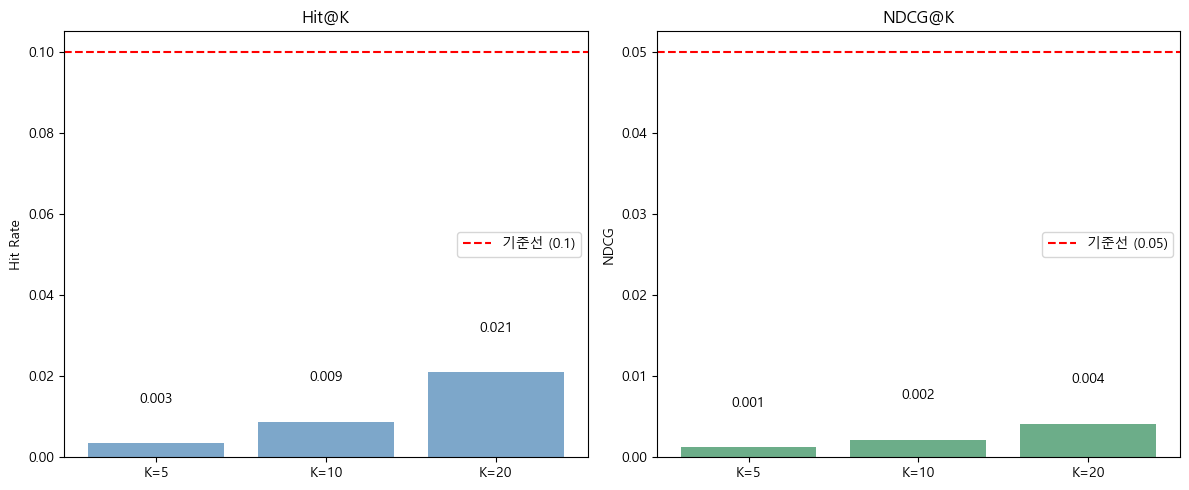

In [ ]:
# 평가 지표 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Hit@K
ax1 = axes[0]
k_labels = [f'K={k}' for k in k_values]
hit_values = [hit_results[k] for k in k_values]
bars1 = ax1.bar(k_labels, hit_values, color='steelblue', alpha=0.7)
ax1.axhline(y=HIT_THRESHOLD, color='red', linestyle='--', label=f'기준선 ({HIT_THRESHOLD})')
ax1.set_ylabel('Hit Rate')
ax1.set_title('Hit@K')
ax1.legend()
for bar, val in zip(bars1, hit_values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center')

# NDCG@K
ax2 = axes[1]
ndcg_values = [ndcg_results[k] for k in k_values]
bars2 = ax2.bar(k_labels, ndcg_values, color='seagreen', alpha=0.7)
ax2.axhline(y=NDCG_THRESHOLD, color='red', linestyle='--', label=f'기준선 ({NDCG_THRESHOLD})')
ax2.set_ylabel('NDCG')
ax2.set_title('NDCG@K')
ax2.legend()
for bar, val in zip(bars2, ndcg_values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}', ha='center')

plt.tight_layout()
plt.show()

## 5. t-SNE 시각화

임베딩을 2D로 축소하여 클러스터링 품질을 시각적으로 확인합니다.

In [ ]:
# 제품 임베딩 t-SNE 시각화
print("t-SNE 변환 중... (시간이 걸릴 수 있습니다)")

# 샘플링 (제품이 많으면 일부만 사용)
MAX_SAMPLES = 1000
n_products = product_embeddings.shape[0]

if n_products > MAX_SAMPLES:
    sample_indices = np.random.choice(n_products, MAX_SAMPLES, replace=False)
    product_embeddings_sample = product_embeddings[sample_indices]
    sample_categories = [product_categories.get(idx_to_product_id.get(i), -1) for i in sample_indices]
else:
    product_embeddings_sample = product_embeddings
    sample_indices = range(n_products)
    sample_categories = [product_categories.get(idx_to_product_id.get(i), -1) for i in sample_indices]

print(f"샘플 수: {len(sample_indices)}")

# t-SNE 실행
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(sample_indices)-1))
embeddings_2d = tsne.fit_transform(product_embeddings_sample)

print("t-SNE 완료")

t-SNE 변환 중... (시간이 걸릴 수 있습니다)
샘플 수: 1000
t-SNE 완료


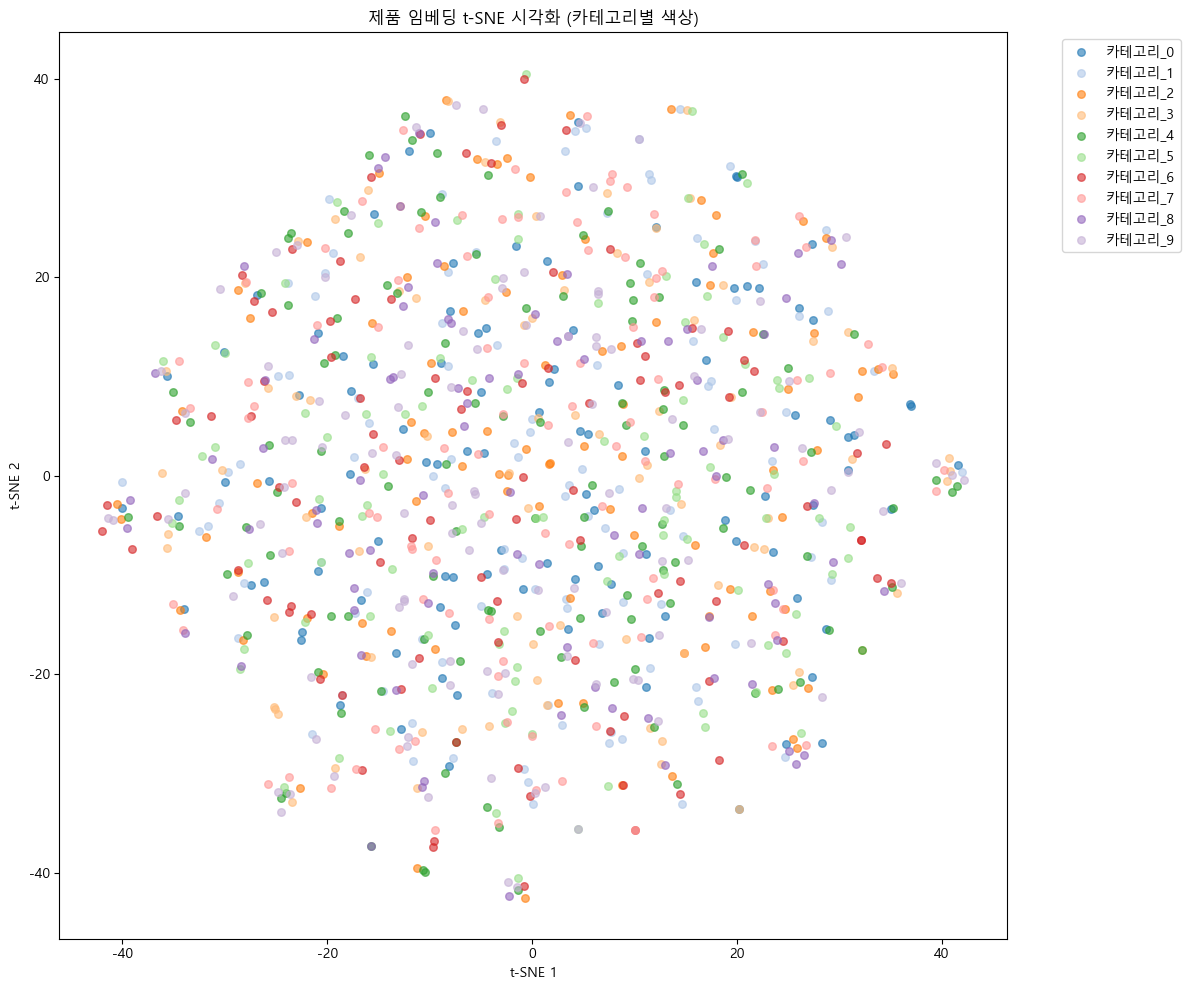

In [ ]:
# t-SNE 결과 시각화
fig, ax = plt.subplots(figsize=(12, 10))

# 카테고리별 색상
unique_categories = list(set(sample_categories))
n_colors = len(unique_categories)
colors = plt.cm.tab20(np.linspace(0, 1, max(n_colors, 20)))
color_map = {cat: colors[i % 20] for i, cat in enumerate(unique_categories)}

# 산점도
for cat in unique_categories:
    mask = np.array(sample_categories) == cat
    cat_name = category_names.get(cat, f"카테고리_{cat}")
    ax.scatter(
        embeddings_2d[mask, 0], 
        embeddings_2d[mask, 1],
        c=[color_map[cat]],
        label=cat_name[:15],  # 레이블 길이 제한
        alpha=0.6,
        s=30
    )

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('제품 임베딩 t-SNE 시각화 (카테고리별 색상)')

# 범례 (카테고리가 많으면 일부만 표시)
if n_colors <= 15:
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# 사용자 임베딩 t-SNE (사용자 타입별)
print("사용자 임베딩 t-SNE 변환 중...")

# 사용자 타입 분류 (상호작용 수 기반)
if 'user_types' in svd_results.get('metadata', {}):
    user_types = svd_results['metadata']['user_types']
else:
    # 시뮬레이션: 무작위 타입 할당
    np.random.seed(42)
    user_types = {}
    for user_id in idx_to_user_id.values():
        user_types[user_id] = np.random.choice(['cold', 'lukewarm', 'warm'], p=[0.2, 0.5, 0.3])

# 샘플링
n_users = user_embeddings.shape[0]
MAX_USER_SAMPLES = 500

if n_users > MAX_USER_SAMPLES:
    user_sample_indices = np.random.choice(n_users, MAX_USER_SAMPLES, replace=False)
    user_embeddings_sample = user_embeddings[user_sample_indices]
else:
    user_sample_indices = range(n_users)
    user_embeddings_sample = user_embeddings

sample_user_types = [user_types.get(idx_to_user_id.get(i), 'unknown') for i in user_sample_indices]

# t-SNE
tsne_user = TSNE(n_components=2, random_state=42, perplexity=min(30, len(user_sample_indices)-1))
user_embeddings_2d = tsne_user.fit_transform(user_embeddings_sample)

print("사용자 t-SNE 완료")

사용자 임베딩 t-SNE 변환 중...
사용자 t-SNE 완료


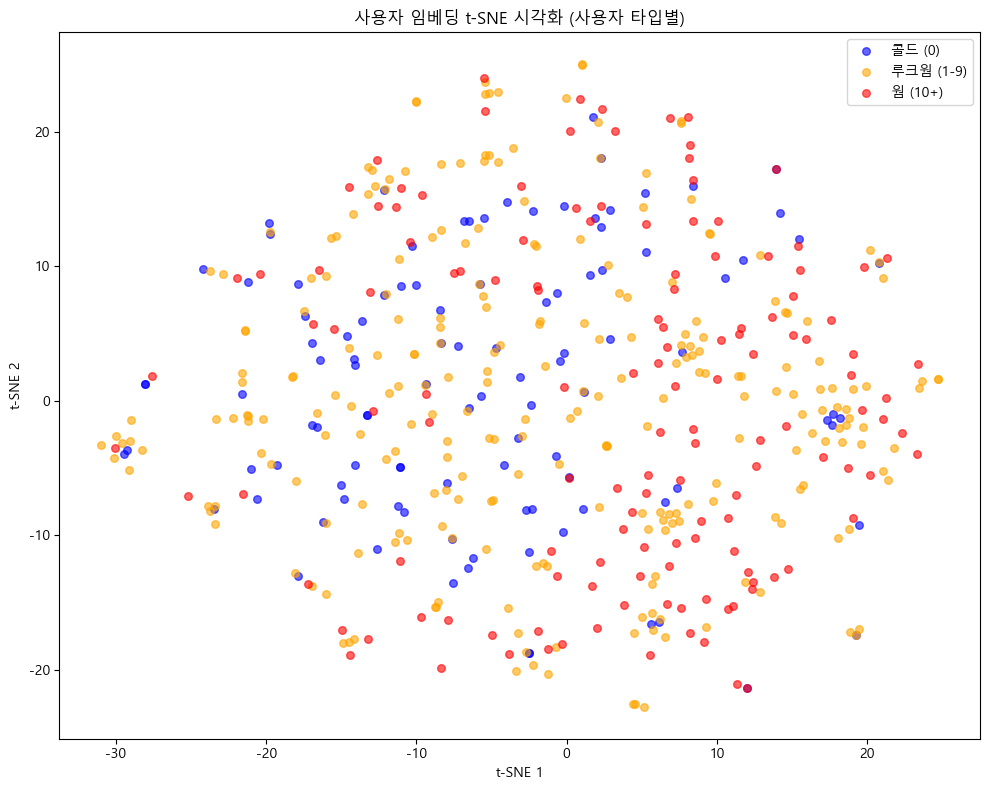

In [ ]:
# 사용자 t-SNE 시각화
fig, ax = plt.subplots(figsize=(10, 8))

type_colors = {'cold': 'blue', 'lukewarm': 'orange', 'warm': 'red', 'unknown': 'gray'}
type_labels = {'cold': '콜드 (0)', 'lukewarm': '루크웜 (1-9)', 'warm': '웜 (10+)', 'unknown': '알 수 없음'}

for user_type, color in type_colors.items():
    mask = np.array(sample_user_types) == user_type
    if mask.sum() > 0:
        ax.scatter(
            user_embeddings_2d[mask, 0],
            user_embeddings_2d[mask, 1],
            c=color,
            label=type_labels[user_type],
            alpha=0.6,
            s=30
        )

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('사용자 임베딩 t-SNE 시각화 (사용자 타입별)')
ax.legend()

plt.tight_layout()
plt.show()

## 6. 임베딩 품질 종합 평가

In [ ]:
# 종합 평가 결과
print("=" * 60)
print("임베딩 품질 종합 평가 결과")
print("=" * 60)

evaluation_results = {
    'product_similarity': {
        'same_category_ratio': product_sim_results['overall_same_category_ratio'],
        'threshold': THRESHOLD_SAME_CATEGORY,
        'passed': product_sim_results['overall_same_category_ratio'] >= THRESHOLD_SAME_CATEGORY
    },
    'holdout_metrics': {
        'hit_at_10': hit_results[10],
        'hit_threshold': HIT_THRESHOLD,
        'hit_passed': hit_results[10] >= HIT_THRESHOLD,
        'ndcg_at_10': ndcg_results[10],
        'ndcg_threshold': NDCG_THRESHOLD,
        'ndcg_passed': ndcg_results[10] >= NDCG_THRESHOLD
    },
    'metadata': {
        'n_users': user_embeddings.shape[0],
        'n_products': product_embeddings.shape[0],
        'embedding_dim': user_embeddings.shape[1],
        'use_real_data': USE_REAL_DATA
    }
}

# 출력
print("\n1. 제품 유사도 테스트")
print(f"   동일 카테고리 비율: {evaluation_results['product_similarity']['same_category_ratio']:.2%}")
print(f"   기준: >= {THRESHOLD_SAME_CATEGORY:.0%}")
print(f"   결과: {'✅ 통과' if evaluation_results['product_similarity']['passed'] else '❌ 미통과'}")

print("\n2. Hold-out 평가 (Hit@10)")
print(f"   Hit@10: {evaluation_results['holdout_metrics']['hit_at_10']:.4f}")
print(f"   기준: >= {HIT_THRESHOLD}")
print(f"   결과: {'✅ 통과' if evaluation_results['holdout_metrics']['hit_passed'] else '❌ 미통과'}")

print("\n3. Hold-out 평가 (NDCG@10)")
print(f"   NDCG@10: {evaluation_results['holdout_metrics']['ndcg_at_10']:.4f}")
print(f"   기준: >= {NDCG_THRESHOLD}")
print(f"   결과: {'✅ 통과' if evaluation_results['holdout_metrics']['ndcg_passed'] else '❌ 미통과'}")

# 전체 통과 여부
all_passed = all([
    evaluation_results['product_similarity']['passed'],
    evaluation_results['holdout_metrics']['hit_passed'],
    evaluation_results['holdout_metrics']['ndcg_passed']
])

print("\n" + "=" * 60)
if all_passed:
    print("✅ 전체 품질 검증 통과 - Pickle 생성 진행 가능")
else:
    print("⚠️ 일부 기준 미통과 - 하이퍼파라미터 조정 또는 데이터 검토 필요")
    print("   (시뮬레이션 데이터의 경우 미통과는 예상된 결과입니다)")
print("=" * 60)

임베딩 품질 종합 평가 결과

1. 제품 유사도 테스트
   동일 카테고리 비율: 10.14%
   기준: >= 60%
   결과: ❌ 미통과

2. Hold-out 평가 (Hit@10)
   Hit@10: 0.0088
   기준: >= 0.1
   결과: ❌ 미통과

3. Hold-out 평가 (NDCG@10)
   NDCG@10: 0.0022
   기준: >= 0.05
   결과: ❌ 미통과

⚠️ 일부 기준 미통과 - 하이퍼파라미터 조정 또는 데이터 검토 필요
   (시뮬레이션 데이터의 경우 미통과는 예상된 결과입니다)


In [ ]:
# 평가 결과 저장
OUTPUT_DIR = Path('../data/processed/self')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

evaluation_output_path = OUTPUT_DIR / 'svd_evaluation_results.pkl'

with open(evaluation_output_path, 'wb') as f:
    pickle.dump(evaluation_results, f)

print(f"평가 결과 저장 완료: {evaluation_output_path}")

평가 결과 저장 완료: ..\data\processed\self\svd_evaluation_results.pkl


## 7. 검증 체크리스트

다음 단계(23번 노트북 - Pickle 생성)로 진행하기 전 확인 사항:

### 필수 확인 항목
- [ ] SVD 결과 파일 로드 성공
- [ ] 제품 유사도 테스트 실행 완료
- [ ] Hold-out 평가 (Hit@K, NDCG@K) 실행 완료
- [ ] t-SNE 시각화 확인
- [ ] 평가 결과 파일 저장 완료

### 품질 기준 (권장)
- [ ] 동일 카테고리 비율 >= 60%
- [ ] Hit@10 >= 0.1
- [ ] NDCG@10 >= 0.05

### 참고 사항
- 시뮬레이션 데이터를 사용한 경우 품질 기준 미달은 정상입니다
- 실제 DB 데이터로 평가해야 정확한 품질 측정이 가능합니다
- 품질 기준 미달 시 하이퍼파라미터 조정이 필요할 수 있습니다:
  - SVD 차원 수 조정 (64 ↔ 128 ↔ 256)
  - 상호작용 가중치 조정 (view, cart, order)
  - 로그 변환 강도 조정